In [ ]:
# # IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# # RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()

In [ ]:
# # IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# # THEN FEEL FREE TO DELETE THIS CELL.
# # NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# # ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.

# stphaneaholoubah_fr_audio_dataset_path = kagglehub.dataset_download('stphaneaholoubah/fr-audio-dataset')

# print('Data source import complete.')

In [ ]:
# %%capture
# !pip install evaluate jiwer tensorboard datasets[audio] librosa soundfile

In [ ]:
%%capture
!pip install -q transformers torchaudio jiwer librosa soundfile wordcloud umap-learn scikit-learn python-levenshtein pandas matplotlib tqdm accelerate bitsandbytes

In [ ]:
#!pip install transformers>=4.41 torchaudio jiwer==3.0.4 librosa==0.10.2.post1 soundfile wordcloud scikit-learn umap-learn matplotlib pandas numpy tqdm


In [ ]:
# from pathlib import Path
# import json, re, numpy as np, pandas as pd, torch, librosa, soundfile as sf
# from tqdm import tqdm
# from transformers import WhisperProcessor, WhisperForConditionalGeneration
# from jiwer import wer, cer
# from sklearn.metrics.pairwise import cosine_distances
# import matplotlib.pyplot as plt

In [ ]:
from pathlib import Path

import os, torch, torchaudio, librosa, soundfile as sf
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

from datasets import Dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration

from jiwer import wer, cer
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics.pairwise import cosine_distances
import umap
import Levenshtein as Lev

In [ ]:
# from kaggle_secrets import UserSecretsClient
# from huggingface_hub import login
# user_secrets = UserSecretsClient()
# HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
# login(token=HF_TOKEN)

In [ ]:
# path = "/kaggle/input/fr-audio-dataset/Collecte_Audio_FR_Radiologie2/Collecte_Audio_FR_Radiologie"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Collecte_Audio_FR_Radiologie"

Mounted at /content/drive


In [ ]:
# Charger le dictionnaire dico_corpus.json
with open(path + '/dico_corpus.json', 'r') as f:
  dico_corpus = json.load(f)

In [ ]:
records = []
for idx, meta in dico_corpus.items():
    try:
        folder = f"{path}/{meta['identifiant']}"
        # parcourir tous les fichiers .wav (ou .mp3) dans le dossier
        for fname in os.listdir(folder):
            if fname.endswith(('.wav', '.flac', '.mp3', '.webm')):
                records.append({
                    "audio": os.path.join(folder, fname),
                    "text": meta['contenu']
                })
    except FileNotFoundError:
        print(f"Dossier introuvable ou vide : {folder}")
    except Exception as e:
        print(f"Erreur inattendue pour {folder} : {e}")

Normalisation de texte

In [ ]:
def normalize_text(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    # text = re.sub(r'[^\w\s]', ' ', text)  # Remplacer ponctuation par espace
    # text = re.sub(r'(\d+)', r' \1 ', text)  # Espacer les chiff
    return text

# records = list(map(lambda r: normalize_text(r["text"]), records))
for record in records:
    record['text'] = normalize_text(record['text'])

In [ ]:
print(records[0])

{'audio': '/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_CnGIjpEu9WIl3lJXeIdIY7Cd-txSUNoMToy_TWma32Y/recorded_audio (7).wav', 'text': 'fracture peu déplacée du col huméral.'}


Reservation d'ensemble de test après entraînement

| Fichier audio                                                                                                                    | Catégorie                                                              |
| -------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------- |
|Collecte\_Audio\_FR\_Radiologie/report\_NxSmAyYz42CeH1IRNJXaSVSHMRR\_WJ0IF0bvxM7z2Ak/recorded\_audio.wav  | Colonne cervicale : examen normal                                      |
|Collecte\_Audio\_FR\_Radiologie/report\_oqzb78c\_pgfdiw1j5VE7h2EbK8pDy6JzqpeZG0SBT2Q/recorded\_audio.wav  | Colonne cervicale : discarthrose et uncarthrose                        |
|Collecte\_Audio\_FR\_Radiologie/report\_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded\_audio.wav   | Colonne lombaire : discarthrose + scoliose + antélisthésis             |
|Collecte\_Audio\_FR\_Radiologie/report\_aOw5Iu1dR7gITUx4qsYWzVqkf8z1FaHIvXKc4vZS2LA/recorded\_audio.wav   | Colonne lombaire : discopathie L3–S1                                   |
|Collecte\_Audio\_FR\_Radiologie/report\_KXz0PIoW4XbD-b2l7CESbvRebk3l57NMa5-hcUrl6Co/recorded\_audio.wav   | Colonne dorsale/lombaire : tassement vertébral T12 + discopathie L4–L5 |
|Collecte\_Audio\_FR\_Radiologie/report\_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm\_NqpZKI7BYyg/recorded\_audio.wav  | Colonne cervicale : raideur avec lordose effacée                       |
|Collecte\_Audio\_FR\_Radiologie/report\_8BAs0TZXB8Ws9zn7KBV93ppcUo5CuywO\_FzNxSfxXNs/recorded\_audio.wav  | Colonne lombaire : discarthrose débutante L2–L4                        |
|Collecte\_Audio\_FR\_Radiologie/report\_9OugJTY\_WxUoOJ33vQwAYsol4zHP\_dcjAURHmHGKPfA/recorded\_audio.wav | Épaule : fracture du col de l’humérus                                  |
|Collecte\_Audio\_FR\_Radiologie/report\_QxjI35WATxkcOthJzYrmpFFdVz7Etu70eKJ-WuYocSk/recorded\_audio.wav   | Épaule : disjonction acromio‑claviculaire                              |
|Collecte\_Audio\_FR\_Radiologie/report\_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded\_audio.wav   | Épaule : luxation gléno‑humérale antéro‑interne                        |
|Collecte\_Audio\_FR\_Radiologie/report\_k1S-S-2HekY8y8o-\_hNrQvTmYvezomCCJyD7S5\_Qn2g/recorded\_audio.wav | Épaule : arthrose acromio‑claviculaire bilatérale                      |
|Collecte\_Audio\_FR\_Radiologie/report\_ohuSPicvcj6wDc064GnEXhdkQW4Z9vJCTq5ItHnkyqM/recorded\_audio.wav   | Épaule : fracture de la scapula + disjonction acromio‑claviculaire     |
|Collecte\_Audio\_FR\_Radiologie/report\_mammographie\_140/recorded\_audio.wav                             | Mammographie : seins type C, examen ACR0 (normal)                      |
|Collecte\_Audio\_FR\_Radiologie/report\_mammographie\_148/recorded\_audio.wav                             | Mammographie : seins type B avec kyste (seins droit ACR2)              |
|Collecte\_Audio\_FR\_Radiologie/report\_yP4Wtno91JVex6cd4izFsQ06267flev6YdydB8rjebI/recorded\_audio.wav   | Thorax : pneumopathie bilatérale à prédominance droite                 |
|Collecte\_Audio\_FR\_Radiologie/report\_rst1Vqx2nrf-r0U51UuevbXdLwxDnhKnjmYjXJAk1ww/recorded\_audio.wav   | Extrémité : fracture de la phalange distale de l’hallux                |
|Collecte\_Audio\_FR\_Radiologie/report\_WPaxdNrHQGE14sctuPQ4DOFp\_wb8vtgP5StxXZJ37Hg/recorded\_audio.wav  | Tête : otomastoïdite gauche (rocher gauche)                            |


In [ ]:
test_audios = [
    "/report_NxSmAyYz42CeH1IRNJXaSVSHMRR_WJ0IF0bvxM7z2Ak/recorded_audio.wav",
    "/report_oqzb78c_pgfdiw1j5VE7h2EbK8pDy6JzqpeZG0SBT2Q/recorded_audio.wav",
    "/report_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded_audio.wav",
    "/report_aOw5Iu1dR7gITUx4qsYWzVqkf8z1FaHIvXKc4vZS2LA/recorded_audio.wav",
    "/report_KXz0PIoW4XbD-b2l7CESbvRebk3l57NMa5-hcUrl6Co/recorded_audio.wav",
    "/report_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm_NqpZKI7BYyg/recorded_audio.wav",
    "/report_8BAs0TZXB8Ws9zn7KBV93ppcUo5CuywO_FzNxSfxXNs/recorded_audio.wav",
    "/report_9OugJTY_WxUoOJ33vQwAYsol4zHP_dcjAURHmHGKPfA/recorded_audio.wav",
    "/report_QxjI35WATxkcOthJzYrmpFFdVz7Etu70eKJ-WuYocSk/recorded_audio.wav",
    "/report_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded_audio.wav",
    "/report_k1S-S-2HekY8y8o-_hNrQvTmYvezomCCJyD7S5_Qn2g/recorded_audio.wav",
    "/report_ohuSPicvcj6wDc064GnEXhdkQW4Z9vJCTq5ItHnkyqM/recorded_audio.wav",
    "/report_mammographie_140/recorded_audio.wav",
    "/report_mammographie_148/recorded_audio.wav",
    "/report_yP4Wtno91JVex6cd4izFsQ06267flev6YdydB8rjebI/recorded_audio.wav",
    "/report_rst1Vqx2nrf-r0U51UuevbXdLwxDnhKnjmYjXJAk1ww/recorded_audio.wav",
    "/report_WPaxdNrHQGE14sctuPQ4DOFp_wb8vtgP5StxXZJ37Hg/recorded_audio.wav"
]

In [ ]:
# fold_path = "/kaggle/input/fr-audio-dataset/Collecte_Audio_FR_Radiologie2/Collecte_Audio_FR_Radiologie"
# eval_audios = [fold_path + r_path for r_path in eval_audios]
test_audios = [path + r_path for r_path in test_audios]

In [ ]:
# Create a set of audio paths for the test set
test_audio_paths = set(test_audios)

# Create a new list for test records
test_records = [record for record in records if record["audio"] in test_audio_paths]

# Filter the original records list to remove the test records
records = [record for record in records if record["audio"] not in test_audio_paths]

Création du dataset

In [ ]:
# Créer le dataset à partir de la liste
#ds = Dataset.from_list(records)
test_ds = Dataset.from_list(test_records)
# Indiquer que la colonne "audio" contient des fichiers audio
#ds = ds.cast_column("audio", Audio(sampling_rate=16_000))

In [ ]:
# # Remove the path prefix from the audio filenames
# def remove_prefix(example):
#     example["audio"] = example["audio"].replace(path + "/", "")
#     return example

# # Apply the function to the test dataset
# test_ds = test_ds.map(remove_prefix)

# # Save the dataset to a CSV file
# test_df = test_ds.to_pandas()
# test_df.to_csv("test_dataset.csv", index=False)

# print("Training dataset created and saved to train_dataset.csv")

In [ ]:
# test_df

In [ ]:
def load_audio_mono_16k(path: str):
    wav, sr = torchaudio.load(path)                   # gère wav/mp3/flac (selon backend)
    if wav.dim() == 2:
        wav = wav.mean(dim=0)                         # -> mono
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav.numpy()

## Listes de termes médicaux choisis pour l'évaluation

In [ ]:
medical_words = ["vertébral", "vertébraux","para‑vertébrales","tassement","postérieur","minéralisation","vertébrale","pincement","ostéophytes",
                 "inter‑vertébral","fracture","ostéophyte","corporéaux","acromio‑claviculaire","gléno‑humérale","inter‑vertébraux","péri‑articulaires",
                 "symétriques","cervical","déminéralisation","calcifiante","rotateurs","tendinopathie","antélisthésis","convexité","distorsion","nodulaire",
                 "scoliose","asymétrie","cervicale","focalisée","axillaire","cranio‑caudale","médio‑latérale‑oblique","palpation","tissulaire","écoulement",
                 "calcique","discopathie","gynécologique","uncarthrose","antérieur","clavicule","disjonction","déhiscence","intracrânien","pulmonaire",
                 "bilatérale","conjugaison","ostéocondensation","costo‑diaphragmatiques","foraminal","micro‑calcification","rétrécissement","épanchement",
                 "comblement","déviation","intraveineuse","rétro‑aréolaire","thoracique","échographie","adénomégalie","arthrose","cartilages","discal",
                 "enthesopathie","fémoro‑tibial","gonarthrose","rachidienne","semi‑circulaires","tympanique","ossiculaire","mastoïdienne","procidence",
                 "otomastoidite","cochlée","jugulaire","pneumothorax","pneumopathie","parenchyme","médiastin","pneumatisation","mastoïdiennes","tympanique",
                 "alvéolaire","atélectasie","biliaires","bronchogramme","centimétrique","coxo‑fémorale"
                 ]


## Chargement Modèles

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000

# === LES MODELES ===
MODELS = {
    # """ Vague de Sélection A"""
    # "small_base": "openai/whisper-small", # modele baseline utilisé pour le fine-tuning
    # "small_rad1.1": "StephaneBah/whisper-small-rad-fr1.1", # Encodeur gelé et full fine tuning du Decodeur
    # "small_rad1.2FullFT": "StephaneBah/whisper-small-rad-fr1.2F", # Fine tuning complet(encodeur + decodeur) sans rien gelé
    # "small_rad_lora": "StephaneBah/whisper-small-rad-fr2", # Fine tuning complet en se basant sur LoRA avec QKVO et FFN=False
    # "small_rad_lora2": "StephaneBah/whisper-small-rad-fr3", # Fine tuning complet en se basant sur LoRA avec QKV et FFN=True


    # """Vague de Sélection B """
    # "small_rad2.0": "StephaneBah/whisper-small-rad-fr2.0", # Fine tuning des 4 premières couches de l'encodeur en partant du "small_rad1.1"(c'était le
    # # meilleur modèle issue de notre première selection, les 2.0 sont de la deuxième) déjà fine tuné sur le decodeur. Donc Décodeur gelé pendant l'opération
    # "small_rad2.0_lora_VO_FFN": "StephaneBah/whisper-small-rad-fr2.0_lora", # même approche mais avec LoRA (VO & FFN=True)
    # "small_rad2.O_lora_QKVO_FFN": "StephaneBah/whisper-small-rad-fr2.0_lora2", # même approche mais avec LoRA (QKVO & FFN=True)

    "whisper_small": "openai/whisper-small", # modele baseline utilisé pour le fine-tuning
    "whisper-small-rad-FR1": "StephaneBah/whisper-small-rad-FR1", # Fine Tuning du Decoder avec LoRA
    "whisper-small-rad-FR2": ("StephaneBah/whisper-small-rad-FR2", "731ddf9943a99c95d329b96581c80912af9e8d96"), # Fine Tuning des 4 premières couches de l'encoder à partir de small_rad1
    "whisper-small-rad-FR3": "StephaneBah/whisper-small-rad-FR3",
    "whisper-small-rad-FR4_Combo": "StephaneBah/whisper-small-rad-FR4_Combo"
}

# from transformers import WhisperForConditionalGeneration

# model = WhisperForConditionalGeneration.from_pretrained(
#     "StephaneBah/whisper-small-rad-fr2.0",
#     revision="482c8e350b5e0a877031ae3ec7e4a789cefec13c"  # hash du commit
# )

# === PROCESSOR commun ===
LANG = "fr"
TASK = "transcribe"
processor = WhisperProcessor.from_pretrained("openai/whisper-small", language=LANG, task=TASK)
forced_ids = processor.get_decoder_prompt_ids(language=LANG, task=TASK)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

##Analyse de Representations

In [ ]:
@torch.no_grad()
def transcribe_dataset(model_id: str, ds: Dataset, max_new_tokens=444):
    # Check if model_id is a tuple (model_name, revision)
    if isinstance(model_id, tuple):
        model_name, revision = model_id
        model = WhisperForConditionalGeneration.from_pretrained(model_name, revision=revision).to(DEVICE).eval()
    else:
        model = WhisperForConditionalGeneration.from_pretrained(model_id).to(DEVICE).eval()

    model.generation_config.forced_decoder_ids = forced_ids
    preds, refs, audios = [], [], []

    for r in tqdm(ds, desc=f"Transcribe:{model_id}"):
        # r contient uniquement: r["audio"] et r["text"]
        wav = load_audio_mono_16k(r["audio"])
        if wav is None:  # Skip if audio loading failed
            continue
        inputs = processor(wav, sampling_rate=SAMPLE_RATE, return_tensors="pt").to(DEVICE)

        out_ids = model.generate(
            **inputs,
            # forced_decoder_ids=forced_ids, # Removed this line
            do_sample=False,
            temperature=0.3, #0.5; 0.0
            #num_beams=3, # explore plusieurs séquences en parallèle et garde les meilleures.
            max_new_tokens=max_new_tokens
        )
        # le but est d'évaluer les performances en combinant: "Meilleure transcription possible"
        # et déterminisme (pour rester stable dans l'évaluation)
        hyp = processor.batch_decode(out_ids, skip_special_tokens=True)[0]

        preds.append(hyp)
        refs.append(r["text"])
        audios.append(r["audio"])

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    df = pd.DataFrame({
        "audio": audios,
        "expectations": [normalize_text(x) for x in refs],
        "predictions": [normalize_text(x) for x in preds],
    })
    return df

In [ ]:
# @torch.no_grad()
# def encoder_embeddings(model_id: str, ds: Dataset):
#     model = WhisperForConditionalGeneration.from_pretrained(model_id, language=LANG, task=TASK).to(DEVICE).eval()
#     feats = []
#     for r in tqdm(ds, desc=f"Encoder:{model_id}"):
#         wav = load_audio_mono_16k(r["audio"])
#         inputs = processor(wav, sampling_rate=SAMPLE_RATE, return_tensors="pt").to(DEVICE)
#         enc = model.model.encoder(inputs.input_features)
#         emb = enc.last_hidden_state.mean(dim=1).squeeze(0).detach().cpu().numpy()
#         feats.append(emb)
#     del model
#     if torch.cuda.is_available(): torch.cuda.empty_cache()
#     X = np.vstack(feats)
#     return X

# embeds, rdms = {}, {}
# for name, mid in MODELS.items():
#     X = encoder_embeddings(mid, test_ds)
#     embeds[name] = X
#     rdms[name] = cosine_distances(X)

# # Mantel Spearman entre RDMs (structure représentationnelle)
# from scipy.stats import spearmanr
# def mantel_spearman(A,B):
#     iu = np.triu_indices_from(A, k=1)
#     return spearmanr(A[iu], B[iu]).correlation

# names=list(MODELS.keys())
# for i in range(len(names)):
#     for j in range(i+1, len(names)):
#         rho = mantel_spearman(rdms[names[i]], rdms[names[j]])
#         print(f"RDM Spearman({names[i]} vs {names[j]}): {rho:.3f}")

# # UMAP (sans labels — points non colorés)
# for name in names:
#     X = embeds[name]
#     Z = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)
#     plt.figure(figsize=(6,5))
#     plt.scatter(Z[:,0], Z[:,1], s=50, alpha=.85)
#     plt.title(f"UMAP encodeur — {name}")
#     plt.show()


### Embedding Decoders et UMAP

In [ ]:
@torch.no_grad()
def decoder_seq_embeddings(model_id, ds, processor, forced_ids, sample_rate=SAMPLE_RATE, device=DEVICE):
    # Check if model_id is a tuple (model_name, revision)
    if isinstance(model_id, tuple):
        model_name, revision = model_id
        model = WhisperForConditionalGeneration.from_pretrained(model_name, revision=revision).to(device).eval()
    else:
        model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device).eval()
    model.generation_config.forced_decoder_ids = forced_ids
    seq_embs = []

    for r in tqdm(ds, desc=f"Decoder_Embeddings:{model_id}"):
        wav = load_audio_mono_16k(r["audio"])
        if wav is None:  # Skip if audio loading failed
            continue

        inputs = processor(wav, sampling_rate=sample_rate, return_tensors="pt").to(device)

        # on génère pour obtenir les ids
        gen = model.generate(
            **inputs,
            # forced_decoder_ids=forced_ids, # Removed this line
            do_sample=False,
            temperature=0.0,
            return_dict_in_generate=True,
            output_hidden_states=True,   # on veut les états cachés
            output_attentions=False,
            max_new_tokens=444 # Explicitly set max_new_tokens to a smaller value
        )
        # certaines versions renvoient les états autrement; re-lance un forward propre:
        seq_ids = gen.sequences  # (1, T)
        # forward teacher-forcing pour avoir les hidden_states alignés
        out = model(
            input_features=inputs.input_features,
            decoder_input_ids=seq_ids[:, :-1],       # teacher forcing
            use_cache=False,
            output_hidden_states=True,
            return_dict=True
        )
        # dernière couche du décodeur: [batch=1, T-1, d_model]
        last_dec = out.decoder_hidden_states[-1][0].detach().cpu().numpy()
        seq_embs.append(last_dec.mean(axis=0))      # pooling (T-1) -> (d_model,)

    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.vstack(seq_embs)  # (N, d_model)

# Ex: embeddings pour chaque modèle
embeds = {}
for name, mid in MODELS.items():
    embeds[name] = decoder_seq_embeddings(mid, test_ds, processor, forced_ids, device=DEVICE)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

Decoder_Embeddings:openai/whisper-small:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see 

config.json: 0.00B [00:00, ?B/s]

...

Decoder_Embeddings:StephaneBah/whisper-small-rad-fr3: 100%|██████████| 17/17 [00:35<00:00,  2.07s/it]


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/495M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

Decoder_Embeddings:StephaneBah/whisper-small-rad-FR4_Combo: 100%|██████████| 17/17 [00:43<00:00,  2.54s/it]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


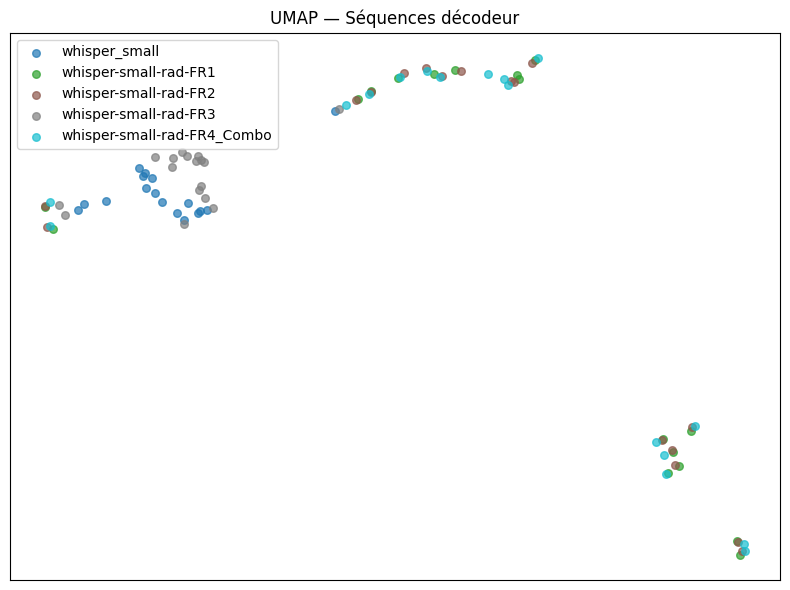

In [ ]:
# Fusionner tous les embeddings en une seule matrice
all_embeds = []
labels = []

for name, emb in embeds.items():
    all_embeds.append(emb)
    labels.extend([name] * len(emb))  # étiquette du modèle pour chaque point

X = np.vstack(all_embeds)  # (total_points, d_model)

# UMAP global
Z = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)

# Plot avec couleurs par modèle
plt.figure(figsize=(8, 6)) # Reduced figure size
unique_labels = list(embeds.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    idxs = [j for j, l in enumerate(labels) if l == label]
    plt.scatter(Z[idxs, 0], Z[idxs, 1], s=30, alpha=0.7, label=label, color=colors[i])

plt.title("UMAP — Séquences décodeur")
plt.legend()
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

###Embedding et RDM

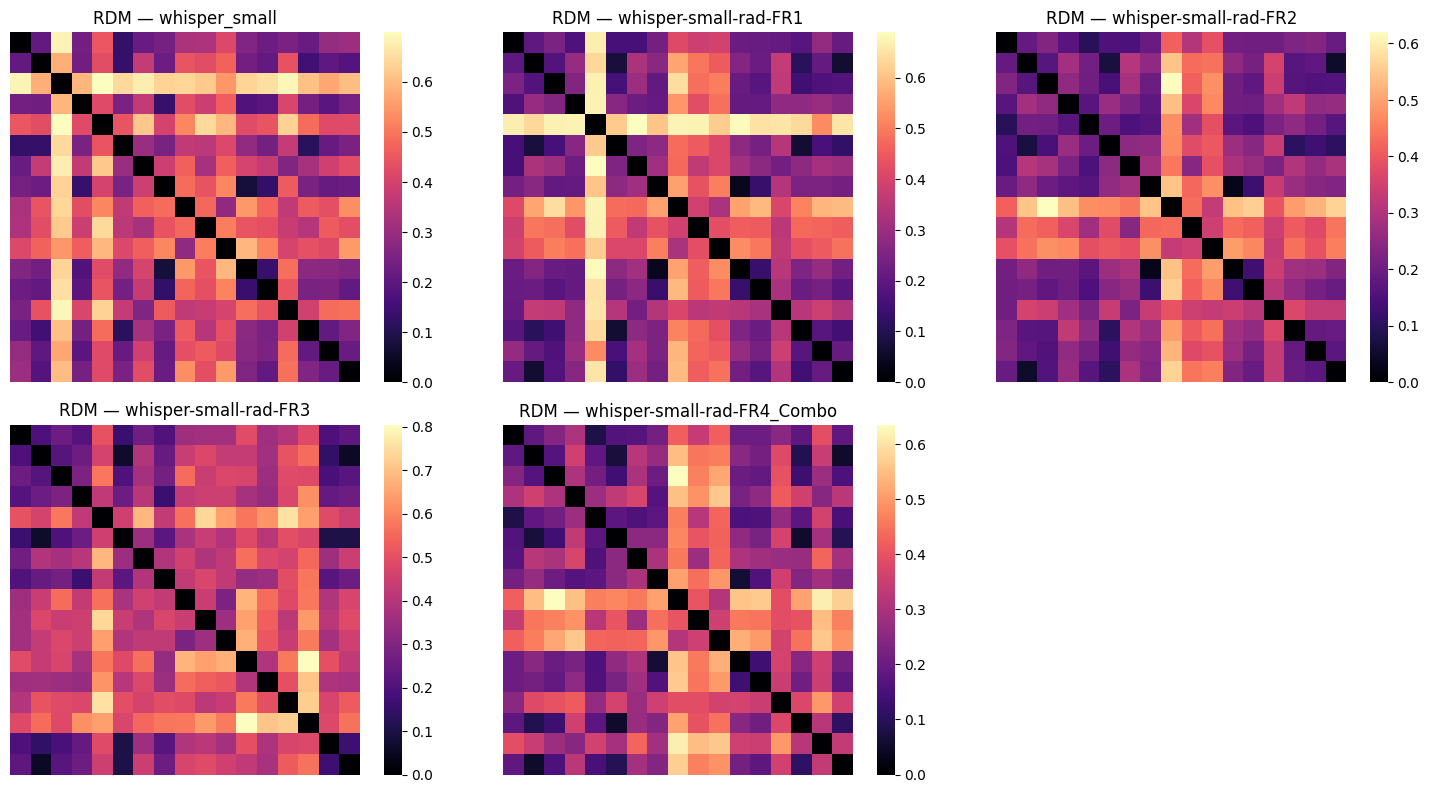

In [ ]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances

# Paramètres de la grille
n_cols = 3  # nombre de colonnes
n_rows = int(np.ceil(len(MODELS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (name, emb) in enumerate(embeds.items()):
    D = cosine_distances(emb)  # (N, N)
    ax = axes[idx]
    sns.heatmap(D, cmap="magma", square=True, ax=ax, cbar=True)
    ax.set_title(f"RDM — {name}")
    ax.set_xticks([]); ax.set_yticks([])

# Supprimer les axes vides si MODELS n'est pas un multiple de n_cols
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Recap

In [ ]:
# Tableau récap global
rows = []
all_eval = {}
for name, mid in MODELS.items():
    edf = transcribe_dataset(mid, test_ds)
    all_eval[name] = edf
    rows.append({"model": name,
                 "WER": wer(edf["expectations"].tolist(), edf["predictions"].tolist()),
                 "CER": cer(edf["expectations"].tolist(), edf["predictions"].tolist()),
                 "Sentence Accuracy": (edf["expectations"]==edf["predictions"]).mean()})
summary_df = pd.DataFrame(rows).sort_values("WER")
display(summary_df)

# Exports
summary_df.to_csv("metrics_global.csv", index=False)
for name, edf in all_eval.items():
    edf[["audio","expectations","predictions"]].to_csv(f"per_file_{name}.csv", index=False)

# Top fichiers les plus difficiles (par modèle)
def per_file_wer(df):
    out=[]
    for _, r in df.iterrows():
        out.append({
            "audio": r["audio"], #Path(r["audio"]).name,
            "wer": wer([r["expectations"]],[r["predictions"]]),
            "cer": cer([r["expectations"]],[r["predictions"]]),
        })
    return pd.DataFrame(out).sort_values("wer", ascending=False)

print("\n=== INSIGHTS RAPIDES ===")
best = summary_df.iloc[0]; base = summary_df[summary_df["model"]=="whisper_small"].iloc[0]
print(f"Meilleur WER: {best['model']} -> {best['WER']:.3f} (CER {best['CER']:.3f}, FullPhrase {best['Sentence Accuracy']:.2%})")
for _, row in summary_df.iterrows():
    if row["model"]=="whisper_small": continue
    print(f"ΔWER vs whisper_small ({row['model']}): {(base['WER']-row['WER'])/base['WER']*100:.1f}%")

# Lister 5 meilleurs fichiers pour le meilleur modèle (à analyser)
best5 = per_file_wer(all_eval[best['model']]).tail(5)
display(best5)


Transcribe:openai/whisper-small:   0%|          | 0/17 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://

,model,WER,CER,Sentence Accuracy
1,whisper-small-rad-FR1,0.419095,0.372259,0.058824
2,whisper-small-rad-FR2,0.436181,0.392932,0.176471
4,whisper-small-rad-FR4_Combo,0.536683,0.427155,0.176471
0,whisper_small,0.824121,0.629976,0.000000
3,whisper-small-rad-FR3,1.008040,0.814080,0.000000



=== INSIGHTS RAPIDES ===
Meilleur WER: whisper-small-rad-FR1 -> 0.419 (CER 0.372, FullPhrase 5.88%)
ΔWER vs whisper_small (whisper-small-rad-FR1): 49.1%
ΔWER vs whisper_small (whisper-small-rad-FR2): 47.1%
ΔWER vs whisper_small (whisper-small-rad-FR4_Combo): 34.9%
ΔWER vs whisper_small (whisper-small-rad-FR3): -22.3%


,audio,wer,cer
2,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.065574,0.025586
1,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.058824,0.011673
16,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.040816,0.013928
5,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.023256,0.006494
10,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.000000,0.000000


In [ ]:
# Top fichiers les plus difficiles (par modèle)
def per_file_wer(df):
    out=[]
    for _, r in df.iterrows():
        out.append({
            "audio": r["audio"], #Path(r["audio"]).name,
            "wer": wer([r["expectations"]],[r["predictions"]]),
            "cer": cer([r["expectations"]],[r["predictions"]]),
        })
    return pd.DataFrame(out).sort_values("wer", ascending=False)

print("\n=== INSIGHTS RAPIDES ===")
best = summary_df.iloc[0]; base = summary_df[summary_df["model"]=="whisper_small"].iloc[0]
print(f"Meilleur WER: {best['model']} -> {best['WER']:.3f} (CER {best['CER']:.3f}, FullPhrase {best['Sentence Accuracy']:.2%})")
for _, row in summary_df.iterrows():
    if row["model"]=="whisper_small": continue
    print(f"ΔWER vs small_base ({row['model']}): {(base['WER']-row['WER'])/base['WER']*100:.1f}%")

# Lister 5 pires fichiers pour le meilleur modèle (à analyser)
worst17 = per_file_wer(all_eval[best['model']]).head(17)
display(worst17)
worst17.to_csv()


=== INSIGHTS RAPIDES ===
Meilleur WER: whisper-small-rad-FR1 -> 0.419 (CER 0.372, FullPhrase 5.88%)
ΔWER vs small_base (whisper-small-rad-FR1): 49.1%
ΔWER vs small_base (whisper-small-rad-FR2): 47.1%
ΔWER vs small_base (whisper-small-rad-FR4_Combo): 34.9%
ΔWER vs small_base (whisper-small-rad-FR3): -22.3%


,audio,wer,cer
9,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,1.000000,0.769231
4,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.863636,0.702643
3,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.820809,0.803859
11,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.491979,0.500790
7,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.478788,0.462591
6,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.375000,0.065934
12,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.211538,0.131707
13,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.166667,0.035088
15,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.164179,0.119141
8,/content/drive/MyDrive/Collecte_Audio_FR_Radio...,0.142857,0.113636


',audio,wer,cer\n9,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded_audio.wav,1.0,0.7692307692307693\n4,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded_audio.wav,0.8636363636363636,0.7026431718061674\n3,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_WPaxdNrHQGE14sctuPQ4DOFp_wb8vtgP5StxXZJ37Hg/recorded_audio.wav,0.8208092485549133,0.8038585209003215\n11,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_mammographie_148/recorded_audio.wav,0.4919786096256685,0.5007898894154819\n7,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_mammographie_140/recorded_audio.wav,0.47878787878787876,0.4625912408759124\n6,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_k1S-S-2HekY8y8o-_hNrQvTmYvezomCCJyD7S5_Qn2g/recorded_audio.wav,0.375,0.06593406593406594\n12,/content/drive/MyDrive/Collecte_Audio_FR_Radiologie/report_yP4Wtno91JVex6cd4izFsQ

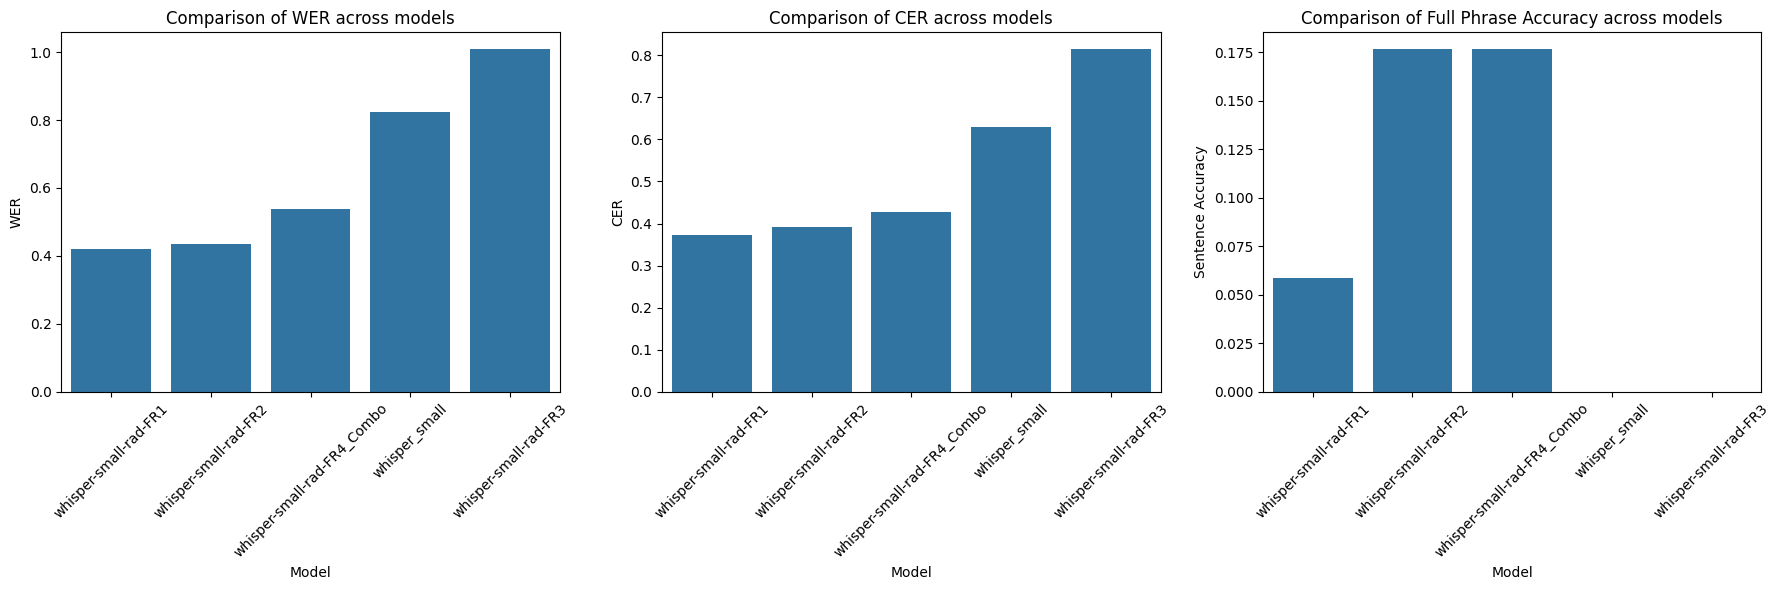

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the dataframe by WER for better visualization
summary_df_sorted = summary_df.sort_values("WER")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# WER plot
sns.barplot(x="model", y="WER", data=summary_df_sorted, ax=axes[0])
axes[0].set_title("Comparison of WER across models")
axes[0].set_ylabel("WER")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=45)

# CER plot
sns.barplot(x="model", y="CER", data=summary_df_sorted, ax=axes[1])
axes[1].set_title("Comparison of CER across models")
axes[1].set_ylabel("CER")
axes[1].set_xlabel("Model")
axes[1].tick_params(axis='x', rotation=45)

# Full Phrase Accuracy plot
sns.barplot(x="model", y="Sentence Accuracy", data=summary_df_sorted, ax=axes[2])
axes[2].set_title("Comparison of Full Phrase Accuracy across models")
axes[2].set_ylabel("Sentence Accuracy")
axes[2].set_xlabel("Model")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
def per_file_metrics(all_eval):
    rows = []
    for model_name, df in all_eval.items():
        for _, r in df.iterrows():
            rows.append({
                "audio": Path(r["audio"]).name,
                "model": model_name,
                "wer": wer([r["expectations"]], [r["predictions"]]),
                "cer": cer([r["expectations"]], [r["predictions"]]),
            })
    return pd.DataFrame(rows)

df_perf = per_file_metrics(all_eval)


Heatmap des WER par fichier et modèle

In [ ]:
# # Check for duplicates before pivoting
# duplicates = df_perf[df_perf.duplicated(subset=['audio', 'model'], keep=False)]

# if not duplicates.empty:
#     print("Found duplicate entries in df_perf:")
#     display(duplicates.sort_values(by=['audio', 'model']))
#     # Handle duplicates, for example, by taking the mean if appropriate
#     # df_perf_cleaned = df_perf.groupby(['audio', 'model']).mean().reset_index()
#     # pivot = df_perf_cleaned.pivot(index="audio", columns="model", values="wer")
# else:
#     pivot = df_perf.pivot(index="audio", columns="model", values="wer")
#     plt.figure(figsize=(12, 8))
#     sns.heatmap(pivot, cmap="viridis", annot=False)
#     plt.title("WER par fichier et par modèle")
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

Boxplot des WER par modèle

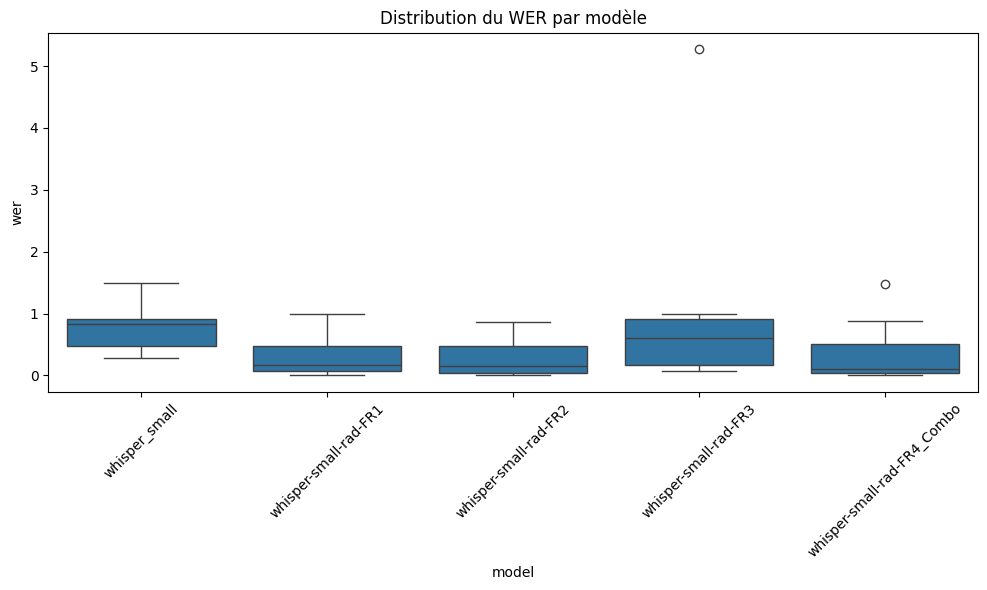

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="model", y="wer", data=df_perf)
plt.title("Distribution du WER par modèle")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Confiance par token (histogrammes de softmax au décodeur)

In [ ]:
# import torch.nn.functional as F

# @torch.no_grad()
# def token_confidences(model_id, ds, processor, forced_ids, sample_rate=16000, device="cuda"):
#     model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device).eval()
#     model.generation_config.forced_decoder_ids = forced_ids
#     conf_all = []
#     for r in ds:
#         wav, sr = torchaudio.load(r["audio"])
#         if wav.dim()==2: wav = wav.mean(dim=0)
#         if sr != sample_rate:
#             wav = torchaudio.functional.resample(wav, sr, sample_rate)
#         inputs = processor(wav.numpy(), sampling_rate=sample_rate, return_tensors="pt").to(device)
#         gen = model.generate(
#             **inputs,
#             # forced_decoder_ids=forced_ids, # Removed this line
#             do_sample=False,
#             temperature=0.0,
#             return_dict_in_generate=True,
#             max_new_tokens=444
#         )
#         seq_ids = gen.sequences  # (1, T)
#         out = model(
#             input_features=inputs.input_features,
#             decoder_input_ids=seq_ids[:, :-1],
#             use_cache=False,
#             output_hidden_states=False,
#             output_attentions=False,
#             return_dict=True
#         )
#         # logits -> proba max par pas
#         # out.logits: [1, T-1, vocab]
#         pmax = F.softmax(out.logits, dim=-1).max(dim=-1).values[0].detach().cpu().numpy()
#         conf_all.append(pmax)  # (T-1,)
#     del model
#     if torch.cuda.is_available(): torch.cuda.empty_cache()
#     # concat variable-length -> histogramme agrégé
#     return np.concatenate(conf_all, axis=0)

# for name, mid in MODELS.items():
#     conf = token_confidences(mid, test_ds, processor, forced_ids, device=DEVICE)
#     plt.figure(figsize=(6,4))
#     plt.hist(conf, bins=30, alpha=.75)
#     plt.title(f"Histogramme des conf. tokens — Décodeur — {name}")
#     plt.xlabel("max softmax prob"); plt.ylabel("Fréquence")
#     plt.show()